# Product Clustering using K-Means
## Project: Product Placement Optimisation
### Purpose: Group similar categories into clusters based on buying behavior
### Input: data/processed/basket_encoded.csv
### Output: Category clusters for placement zone recommendations

## Why Clustering?

Market Basket Analysis told us WHICH categories connect.
K-Means Clustering groups ALL 25 categories into natural
shopping zones based on buying patterns.

This gives us scientific evidence for shelf placement zones.

## Step 1: Load Data and Imports

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
import os
import warnings
warnings.filterwarnings('ignore')

basket_df = pd.read_csv(
    r'D:\softwarica\Sem 6\Individual Project\product-placement-optimization\data\processed\basket_encoded.csv'
)

print("Data loaded successfully!")
print(f"Shape: {basket_df.shape}")
print(f"Categories: {basket_df.columns.tolist()}")

Data loaded successfully!
Shape: (218037, 25)
Categories: ['ALCOHOLIC BEVERAGES', 'BABY CARE', 'BAKERY', 'BISCUITS AND COOKIES', 'BREAKFAST CEREALS', 'CANNED AND PACKAGED FOODS', 'CIGARETTE AND TOBACCO', 'CLEANING SUPPLIES', 'CONFECTIONERY', 'COOKING OIL', 'DAIRY PRODUCTS', 'ELECTRICAL SUPPLIES', 'FOOD STAPLES', 'FROZEN FOODS', 'FRUITS AND VEGETABLES', 'HOUSEHOLD ITEMS', 'NAMKEEN AND SNACKS', 'NOODLES', 'PARTY SUPPLIES', 'PERSONAL CARE', 'POOJA ITEMS', 'RICE', 'SOFT DRINKS AND JUICES', 'STATIONERY', 'TEA AND SPICES']


## Step 2: Prepare Data for Clustering

In [3]:
category_matrix = basket_df.T

scaler = StandardScaler()
category_scaled = scaler.fit_transform(category_matrix)

print("Data prepared for clustering!")
print(f"Categories to cluster: {category_matrix.shape[0]}")
print(f"Features per category: {category_matrix.shape[1]}")

Data prepared for clustering!
Categories to cluster: 25
Features per category: 218037


## Step 3: Find Optimal Number of Clusters (Elbow Method)

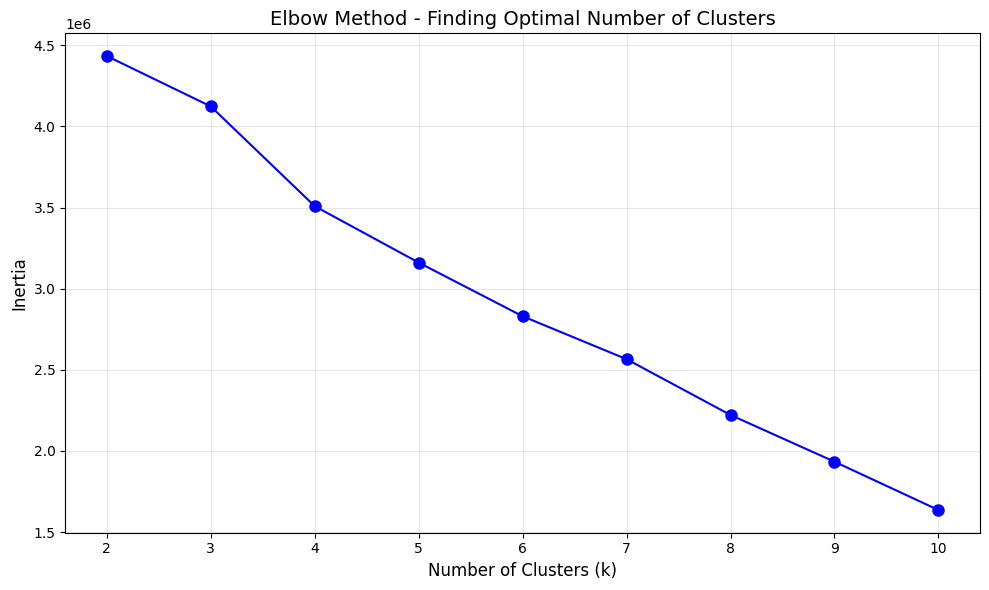

Elbow method chart saved!

Inertia values:
  k=2: 4434195.00
  k=3: 4123577.76
  k=4: 3508642.40
  k=5: 3160872.70
  k=6: 2830209.88
  k=7: 2565476.16
  k=8: 2221599.59
  k=9: 1933600.25
  k=10: 1635781.00


In [4]:
inertia = []
k_range = range(2, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(category_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(10, 6))
plt.plot(k_range, inertia, 'bo-', markersize=8)
plt.xlabel('Number of Clusters (k)', fontsize=12)
plt.ylabel('Inertia', fontsize=12)
plt.title('Elbow Method - Finding Optimal Number of Clusters', fontsize=14)
plt.xticks(k_range)
plt.grid(True, alpha=0.3)
plt.tight_layout()

figures_path = r'D:\softwarica\Sem 6\Individual Project\product-placement-optimization\reports\figures'
os.makedirs(figures_path, exist_ok=True)
plt.savefig(os.path.join(figures_path, 'chart10_elbow_method.png'), dpi=150)
plt.show()
print("Elbow method chart saved!")
print("\nInertia values:")
for k, val in zip(k_range, inertia):
    print(f"  k={k}: {val:.2f}")

## Step 4: Apply K-Means with Optimal k=5

In [5]:
k = 5
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
clusters = kmeans.fit_predict(category_scaled)

category_names = basket_df.columns.tolist()
cluster_df = pd.DataFrame({
    'category': category_names,
    'cluster': clusters
}).sort_values('cluster')

print(f"K-Means clustering complete with k={k}")
print(f"\nCLUSTER ASSIGNMENTS:")
print("=" * 60)
for cluster_id in range(k):
    print(f"\nCLUSTER {cluster_id + 1}:")
    categories = cluster_df[cluster_df['cluster'] == cluster_id]['category'].tolist()
    for cat in categories:
        print(f"  - {cat}")

K-Means clustering complete with k=5

CLUSTER ASSIGNMENTS:

CLUSTER 1:
  - ALCOHOLIC BEVERAGES
  - BABY CARE
  - BAKERY
  - BISCUITS AND COOKIES
  - BREAKFAST CEREALS
  - CIGARETTE AND TOBACCO
  - CLEANING SUPPLIES
  - ELECTRICAL SUPPLIES
  - HOUSEHOLD ITEMS
  - DAIRY PRODUCTS
  - FRUITS AND VEGETABLES
  - FROZEN FOODS
  - PERSONAL CARE
  - PARTY SUPPLIES
  - NOODLES
  - NAMKEEN AND SNACKS
  - TEA AND SPICES
  - RICE
  - SOFT DRINKS AND JUICES
  - STATIONERY
  - POOJA ITEMS

CLUSTER 2:
  - FOOD STAPLES

CLUSTER 3:
  - CANNED AND PACKAGED FOODS

CLUSTER 4:
  - CONFECTIONERY

CLUSTER 5:
  - COOKING OIL


In [6]:
k = 4
kmeans4 = KMeans(n_clusters=k, random_state=42, n_init=10)
clusters4 = kmeans4.fit_predict(category_scaled)

cluster_df4 = pd.DataFrame({
    'category': category_names,
    'cluster': clusters4
}).sort_values('cluster')

print(f"K-Means clustering with k={k}")
print(f"\nCLUSTER ASSIGNMENTS:")
print("=" * 60)
for cluster_id in range(k):
    print(f"\nCLUSTER {cluster_id + 1}:")
    categories = cluster_df4[cluster_df4['cluster'] == cluster_id]['category'].tolist()
    for cat in categories:
        print(f"  - {cat}")

K-Means clustering with k=4

CLUSTER ASSIGNMENTS:

CLUSTER 1:
  - COOKING OIL

CLUSTER 2:
  - ALCOHOLIC BEVERAGES
  - BAKERY
  - BABY CARE
  - BREAKFAST CEREALS
  - CIGARETTE AND TOBACCO
  - CLEANING SUPPLIES
  - BISCUITS AND COOKIES
  - FROZEN FOODS
  - CONFECTIONERY
  - DAIRY PRODUCTS
  - ELECTRICAL SUPPLIES
  - HOUSEHOLD ITEMS
  - FRUITS AND VEGETABLES
  - NOODLES
  - NAMKEEN AND SNACKS
  - TEA AND SPICES
  - RICE
  - PARTY SUPPLIES
  - PERSONAL CARE
  - POOJA ITEMS
  - STATIONERY
  - SOFT DRINKS AND JUICES

CLUSTER 3:
  - CANNED AND PACKAGED FOODS

CLUSTER 4:
  - FOOD STAPLES


## Step 5: Silhouette Score Analysis